## Loading Libraries 

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

## Reading files

In [2]:
df = pd.read_csv("return_predictability_data_2009to2021.csv")
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.sort_values(['DATE'])

In [3]:
df.head()

,permno,DATE,mvel1,beta,betasq,chmom,dolvol,idiovol,indmom,mom1m,...,name,RET,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar
0,10001,2009-01-30,3.549322e+04,1.046713,1.095609,-0.376636,9.010083,0.046476,-0.288060,0.155989,...,ENERGY WEST INC,0.03414,3.383899,4.214465,0.389393,-0.025056,0.0013,-0.1137,0.0309,0.011971
4019,89258,2009-01-30,1.276972e+07,1.635344,2.674351,-0.122023,17.693149,0.040756,-0.388827,0.394470,...,PRUDENTIAL FINANCIAL INC,-0.149042,3.383899,4.214465,0.389393,-0.025056,0.0013,-0.1137,0.0309,0.011971
4018,89257,2009-01-30,4.207965e+05,1.148049,1.318017,-0.279620,12.698907,0.040643,-0.377519,0.461744,...,PIMCO CORP INCOME FUND,-0.000326,3.383899,4.214465,0.389393,-0.025056,0.0013,-0.1137,0.0309,0.011971
4017,89256,2009-01-30,4.425417e+05,0.930163,0.865204,-0.314142,13.625975,0.047899,-0.512504,0.158823,...,NOMURA HOLDINGS INC,-0.22994,3.383899,4.214465,0.389393,-0.025056,0.0013,-0.1137,0.0309,0.011971
4016,89254,2009-01-30,3.175759e+04,1.710565,2.926032,-0.470760,10.166869,0.092895,-0.603886,0.000000,...,GRUPO TMM S A B,0.338028,3.383899,4.214465,0.389393,-0.025056,0.0013,-0.1137,0.0309,0.011971


## EDA

In [4]:
print("Number of rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of rows: 890602
Number of Columns: 107


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
permno,890602.0,NaN,NaN,NaN,60568.189241,10001.0,17789.0,78892.0,89317.0,93436.0,32726.987578
DATE,890602,NaN,NaN,NaN,2015-07-27 07:56:33.911983360,2009-01-30 00:00:00,2012-03-30 00:00:00,2015-07-31 00:00:00,2018-10-31 00:00:00,2021-11-30 00:00:00,NaN
mvel1,890445.0,NaN,NaN,NaN,4813481.881379,88.334997,115152.51486,454699.51294,2047559.1439,2509775134.0,26870059.352258
beta,828951.0,NaN,NaN,NaN,1.073458,-0.165346,0.666723,1.022227,1.413713,3.49403,0.603671
betasq,828951.0,NaN,NaN,NaN,1.52373,0.0,0.448436,1.04806,2.003817,12.429371,1.62916
...,...,...,...,...,...,...,...,...,...,...,...
macro_ntis,890602.0,NaN,NaN,NaN,-0.00556,-0.037427,-0.018606,-0.008357,0.00938,0.026651,0.015281
macro_tbl,890602.0,NaN,NaN,NaN,0.004805,0.0001,0.0005,0.0012,0.0051,0.024,0.007205
macro_tms,890602.0,NaN,NaN,NaN,-0.000567,-0.1137,-0.0209,-0.0024,0.0214,0.086,0.031881
macro_dfy,890602.0,NaN,NaN,NaN,0.010375,0.0055,0.0077,0.0094,0.0117,0.0309,0.004241


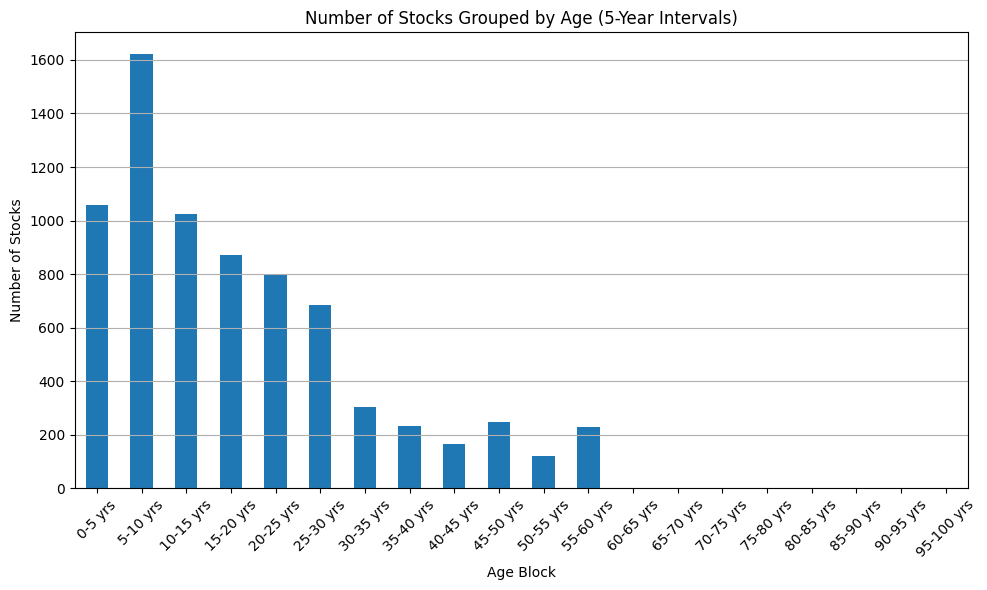

In [6]:
bins = list(range(0, 105, 5))  # 0-5, 5-10, ..., 95-100
labels = [f'{i}-{i+5} yrs' for i in bins[:-1]]
df['age_group_5yrs'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# Now group by stock name (unique companies), taking the most recent age group
# (Assuming multiple rows per stock, let's pick the latest record per company)
latest_date_idx = df.groupby('permno')['DATE'].idxmax()
df_latest = df.loc[latest_date_idx]

# Frequency count of companies per age group
age_group_counts = df_latest['age_group_5yrs'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(10,6))
age_group_counts.plot(kind='bar')
plt.title('Number of Stocks Grouped by Age (5-Year Intervals)')
plt.xlabel('Age Block')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


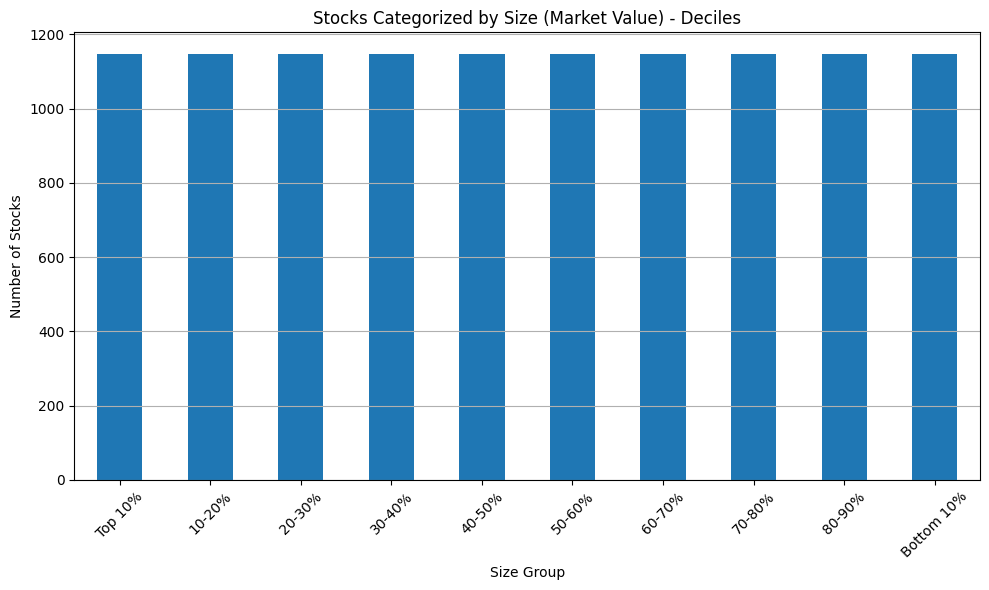

In [7]:
# Remove rows with missing size (mvel1)
df_latest_size = df_latest.dropna(subset=['mvel1'])

# Create size deciles (10 groups from high to low)
df_latest_size['size_decile'] = pd.qcut(df_latest_size['mvel1'], 10, labels=[
    'Top 10%', '10-20%', '20-30%', '30-40%', '40-50%', 
    '50-60%', '60-70%', '70-80%', '80-90%', 'Bottom 10%'
])

# Count number of companies in each size decile
size_decile_counts = df_latest_size['size_decile'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(10,6))
size_decile_counts.plot(kind='bar')
plt.title('Stocks Categorized by Size (Market Value) - Deciles')
plt.xlabel('Size Group')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


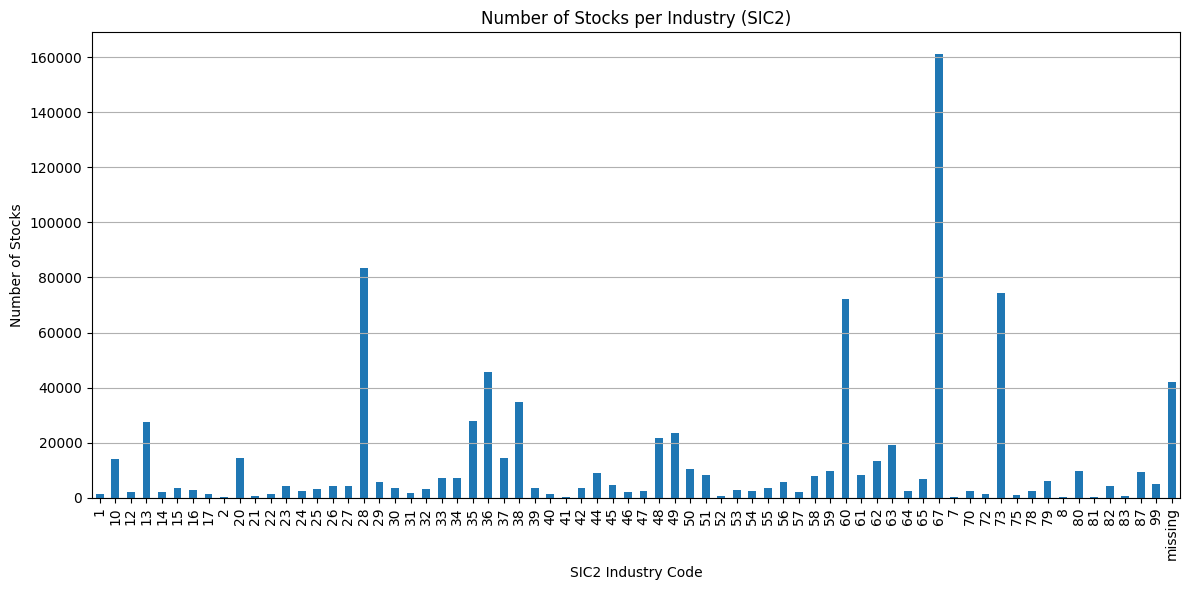

In [8]:
# Group and count number of companies in each SIC2 industry
industry_counts = df['sic2'].value_counts().sort_index()

# Plotting the number of companies per industry
plt.figure(figsize=(12, 6))
industry_counts.plot(kind='bar')
plt.title('Number of Stocks per Industry (SIC2)')
plt.xlabel('SIC2 Industry Code')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


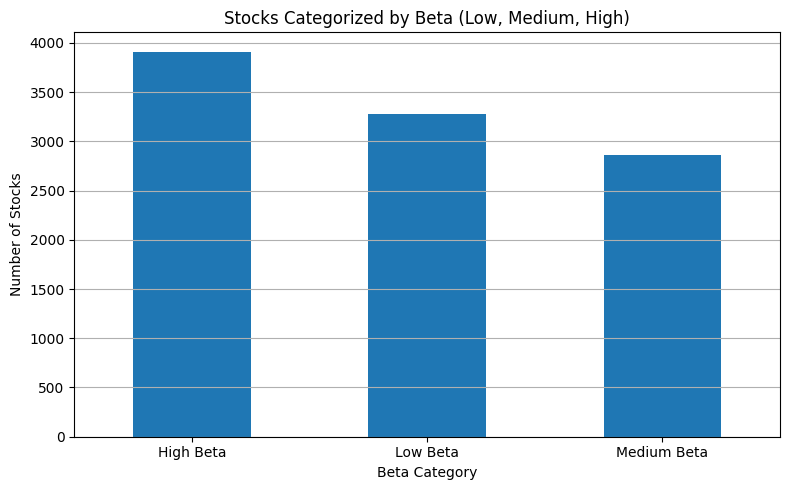

In [9]:
df_latest_beta = df_latest.dropna(subset=['beta'])

# Define thresholds for categorizing beta
# Usually: Low beta (<0.8), Medium (0.8-1.2), High (>1.2)
def categorize_beta(beta):
    if beta < 0.8:
        return 'Low Beta'
    elif 0.8 <= beta <= 1.2:
        return 'Medium Beta'
    else:
        return 'High Beta'

# Apply categorization
df_latest_beta['beta_category'] = df_latest_beta['beta'].apply(categorize_beta)

# Count number of companies in each beta category
beta_category_counts = df_latest_beta['beta_category'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(8, 5))
beta_category_counts.plot(kind='bar')
plt.title('Stocks Categorized by Beta (Low, Medium, High)')
plt.xlabel('Beta Category')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


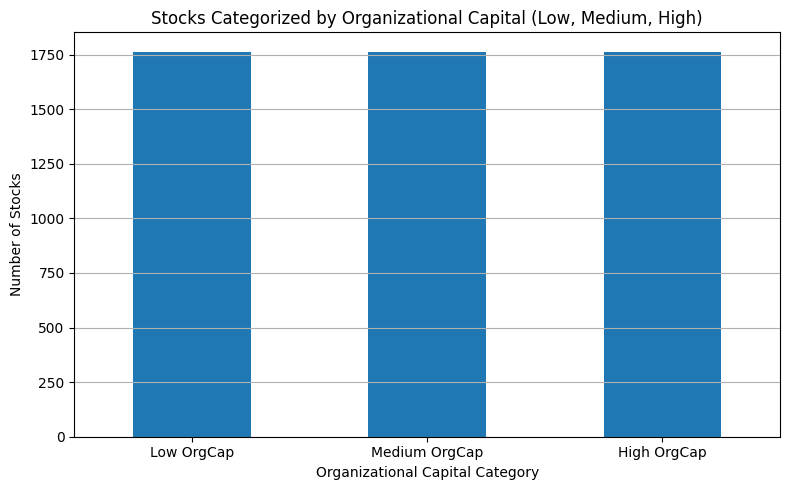

orgcap_category
Low OrgCap       1764
Medium OrgCap    1764
High OrgCap      1764
Name: count, dtype: int64

In [10]:
df_latest_orgcap = df_latest.dropna(subset=['orgcap'])

# Define thresholds for organizational capital
# We'll divide into quantiles: Low (bottom 33%), Medium (middle 33%), High (top 33%)

df_latest_orgcap['orgcap_category'] = pd.qcut(df_latest_orgcap['orgcap'], 3, labels=['Low OrgCap', 'Medium OrgCap', 'High OrgCap'])

# Count number of companies in each orgcap category
orgcap_category_counts = df_latest_orgcap['orgcap_category'].value_counts().sort_index()

# Plotting
plt.figure(figsize=(8, 5))
orgcap_category_counts.plot(kind='bar')
plt.title('Stocks Categorized by Organizational Capital (Low, Medium, High)')
plt.xlabel('Organizational Capital Category')
plt.ylabel('Number of Stocks')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

orgcap_category_counts


## Feature Engineering

In [11]:
annual_features = [
    'absacc', 'acc', 'age', 'agr', 'bm', 'bm_ia', 'cashdebt', 'cashpr', 'cfp', 'cfp_ia',
    'chatoia', 'chcsho', 'chempia', 'chinv', 'convind', 'currat', 'depr', 'divi',
    'divo', 'dy', 'egr', 'ep', 'gma', 'grltnoa', 'herf', 'hire', 'invest', 'lev',
    'lgr', 'mve_ia', 'operprof', 'orgcap', 'pchcapx_ia', 'pchcurrat', 'pchdepr', 'pchgm_pchsale',
    'pchquick', 'pchsale_pchrect', 'pchsale_pchxsga', 'pchsaleinv', 'pctacc',
    'ps', 'quick', 'rd', 'rd_mve', 'rd_sale', 'realestate', 'roic', 'salecash', 'saleinv',
    'salerec', 'secured', 'securedind', 'sgr', 'sin', 'sp', 'tang', 'tb', 'chpmia', 'grcapx', 'pchsale_pchinvt'
]

quarterly_features = [
    'aeavol', 'cash', 'chtx', 'cinvest', 'ms', 'roaq', 'roeq', 'rsup',
    'stdacc', 'stdcf', 'roavol', 'nincr'
]

monthly_features = [
    'baspread', 'beta', 'betasq', 'chmom', 'dolvol', 'ear', 'idiovol', 'ill',
    'indmom', 'maxret', 'mom12m', 'mom1m', 'mom36m', 'mom6m', 'pricedelay',
    'retvol', 'std_dolvol', 'std_turn', 'turn', 'zerotrade', 'macro_dp',
    'macro_ep', 'macro_bm', 'macro_ntis', 'macro_tbl', 'macro_tms', 'macro_dfy', 'macro_svar', 'mvel1'
]

In [12]:
missing_annual = [col for col in annual_features if col not in df.columns]
missing_quarterly = [col for col in quarterly_features if col not in df.columns]
missing_monthly = [col for col in monthly_features if col not in df.columns]

print("Missing Annual Features:", missing_annual)
print("Missing Quarterly Features:", missing_quarterly)
print("Missing Monthly Features:", missing_monthly)

Missing Annual Features: []
Missing Quarterly Features: []
Missing Monthly Features: []


### Categorical Encoding

In [13]:
df['sic2'] = df['sic2'].astype(str)
sic_counts = df['sic2'].value_counts(normalize=True)
rare_sic = sic_counts[sic_counts < 0.05].index
df['sic2'] = df['sic2'].replace(rare_sic, 'Other')
encoder = OneHotEncoder(sparse_output=False, drop='first')
sic_encoded = encoder.fit_transform(df[['sic2']])
sic_encoded_df = pd.DataFrame(sic_encoded, columns=encoder.get_feature_names_out(['sic2']))
df = pd.concat([df.drop('sic2', axis=1), sic_encoded_df], axis=1)

# Drop 'name' (identifier)
df = df.drop('name', axis=1)

### Handling Missing Data

In [14]:
missing_cols = [col for col in df.columns if col not in ['permno', 'DATE', 'name', 'RET', 'sic2']]
missing_cols = df[missing_cols].columns[df[missing_cols].isnull().mean() > 0.1].tolist()
for col in missing_cols:
    df[f'miss_{col}'] = df[col].isnull().astype(int)

# Impute numerical features with median
    imputer = SimpleImputer(strategy='median')
df[annual_features + quarterly_features + monthly_features] = imputer.fit_transform(
    df[annual_features + quarterly_features + monthly_features]
)

### Transformations

In [15]:
# 1. Check and update feature lists
log_features = ['dolvol', 'turn', 'std_dolvol']
log_features = [col for col in log_features if col in df.columns]

to_scale = ['beta', 'mom12m', 'macro_tbl', 'macro_tms', 'macro_svar']
to_scale = [col for col in to_scale if col in df.columns]

rank_features = ['bm', 'ep', 'gma']
rank_features = [col for col in rank_features if col in df.columns]

# 2. Handle invalid values for log-transform
for col in log_features:
    df[col] = df[col].clip(lower=1e-6)
    df[f'log_{col}'] = np.log1p(df[col])

# 3. Ensure no NaNs
df[to_scale + rank_features] = df[to_scale + rank_features].ffill().bfill()

# 5. Percentile ranks with error handling
for col in rank_features:
    try:
        df[f'{col}_decile'] = df.groupby('DATE')[col].transform(
            lambda x: pd.qcut(x, 10, labels=False, duplicates='drop')
        )
    except ValueError:
        df[f'{col}_decile'] = np.nan

### Time Series Features

In [16]:
# Convert to numeric and clean
df['RET'] = pd.to_numeric(df['RET'], errors='coerce')
df['mom6m'] = pd.to_numeric(df['mom6m'], errors='coerce')

# Forward-fill missing values
df['RET'] = df.groupby('permno')['RET'].ffill()
df['mom6m'] = df.groupby('permno')['mom6m'].ffill()

### Feature Selection

In [17]:
# 1. Forward-fill within stock timeline
df['RET'] = df.groupby('permno')['RET'].ffill()

# 2. Fill with monthly market average
df['RET'] = df['RET'].fillna(
    df.groupby('DATE')['RET'].transform('mean')
)

# 3. Final fallback to global median
df['RET'] = df['RET'].fillna(df['RET'].median())

# Verify no missing values
print(df['RET'].isnull().sum())  # Should output 0

0


In [18]:
pd.options.display.max_rows = 999
df.isnull().sum() 

permno                       0
DATE                         0
mvel1                        0
beta                         0
betasq                       0
chmom                        0
dolvol                       0
idiovol                      0
indmom                       0
mom1m                        0
mom6m                        0
mom12m                       0
mom36m                       0
pricedelay                   0
turn                         0
absacc                       0
acc                          0
age                          0
agr                          0
bm                           0
bm_ia                        0
cashdebt                     0
cashpr                       0
cfp                          0
cfp_ia                       0
chatoia                      0
chcsho                       0
chempia                      0
chinv                        0
chpmia                       0
convind                      0
currat                       0
depr    

In [19]:
from sklearn.impute import SimpleImputer

# Clean features
cols_to_convert = df.columns.difference(['permno', 'DATE', 'RET'])  # Changed to df
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')  # Changed

# Update columns
cols_to_convert = df.columns.difference(['permno', 'DATE', 'RET'])  # Changed

# Now define X, y, dates
X = df.drop(['permno', 'DATE', 'RET', 'RET_lag1', 'mom6m_lag3', 'delta_macro_tms', 'rolling_vol', 'age_group_5yrs', 'bm_decile', 'ep_decile', 'gma_decile'], axis=1, errors='ignore')
y = df['RET']
dates = df['DATE']  # Changed to df

# Time split
split_date = dates.quantile(0.8)
train_idx = dates <= split_date
test_idx = dates > split_date

X_train = X[train_idx]
X_test = X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

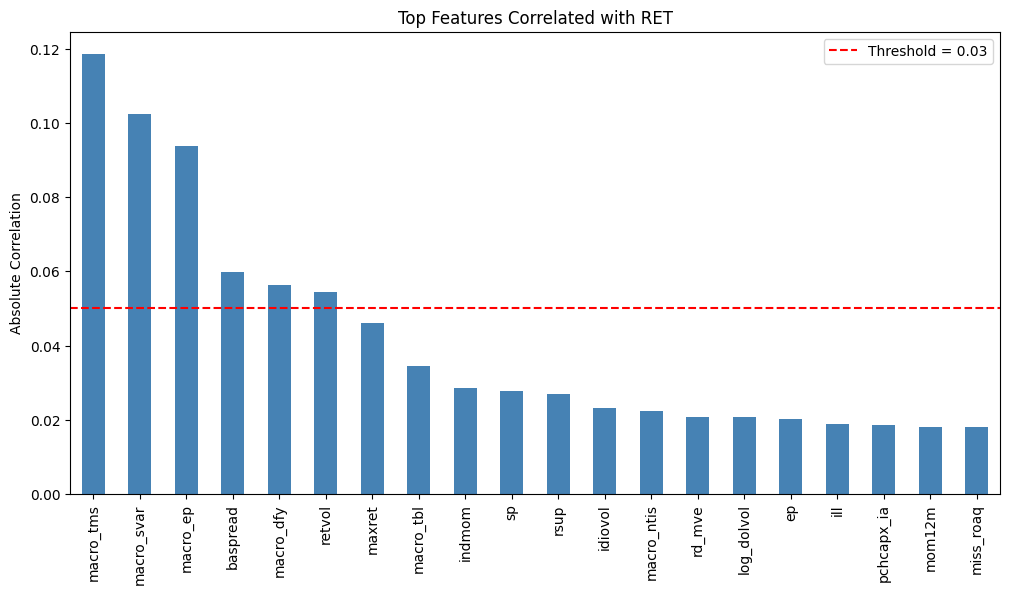


Selected Features: ['macro_tms', 'macro_svar', 'macro_ep', 'baspread', 'macro_dfy', 'retvol', 'maxret', 'macro_tbl']
Final dataset shape: (890602, 11)


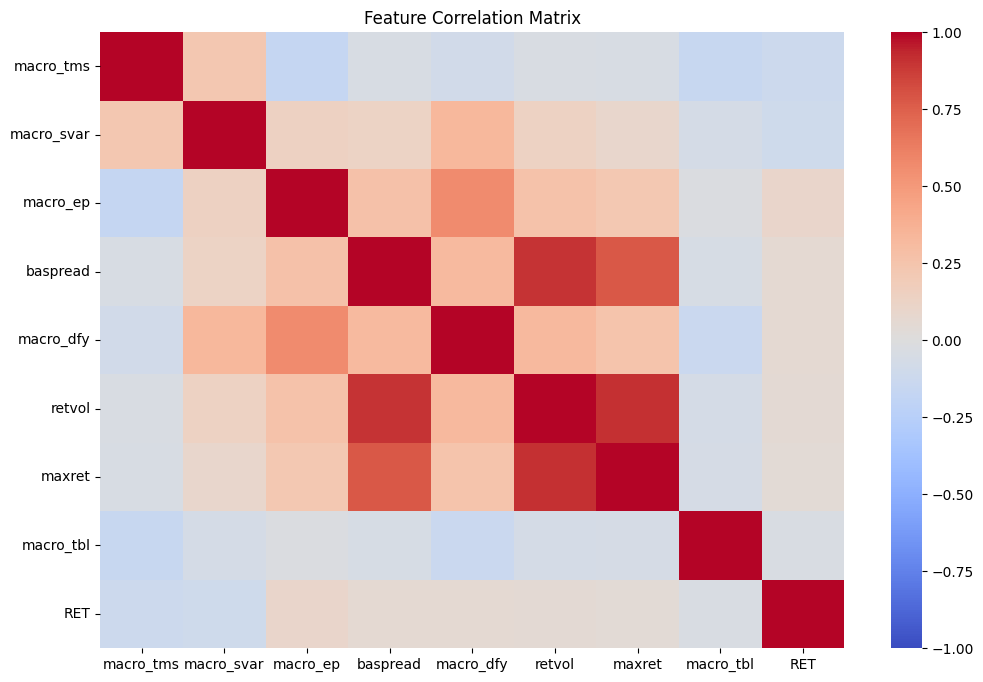

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute absolute correlations with target
corr_with_target = df[cols_to_convert].corrwith(df['RET']).abs().sort_values(ascending=False)

# Plot correlations
plt.figure(figsize=(12, 6))
corr_with_target.head(20).plot(kind='bar', color='steelblue')
plt.title("Top Features Correlated with RET")
plt.ylabel("Absolute Correlation")
plt.axhline(y=0.05, color='red', linestyle='--', label='Threshold = 0.03')
plt.legend()
plt.show()

corr_threshold = 0.03
selected_features = corr_with_target[corr_with_target > corr_threshold].index.tolist()


if not selected_features:
    print("No features above threshold! Using top 5 features.")
    selected_features = corr_with_target.head(5).index.tolist()

df_selected = df[['permno', 'DATE', 'RET'] + selected_features]

print("\nSelected Features:", selected_features)
print("Final dataset shape:", df_selected.shape)

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_selected[selected_features + ['RET']].corr(), 
            cmap='coolwarm', 
            annot=False, 
            vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

In [21]:
df_selected.head()

,permno,DATE,RET,macro_tms,macro_svar,macro_ep,baspread,macro_dfy,retvol,maxret,macro_tbl
0,10001,2009-01-30,0.034140,-0.1137,0.011971,4.214465,0.052282,0.0309,0.035732,0.086957,0.0013
4019,89258,2009-01-30,-0.149042,-0.1137,0.011971,4.214465,0.126506,0.0309,0.109448,0.347189,0.0013
4018,89257,2009-01-30,-0.000326,-0.1137,0.011971,4.214465,0.076023,0.0309,0.051348,0.114094,0.0013
4017,89256,2009-01-30,-0.229940,-0.1137,0.011971,4.214465,0.045393,0.0309,0.046750,0.089172,0.0013
4016,89254,2009-01-30,0.338028,-0.1137,0.011971,4.214465,0.211889,0.0309,0.119972,0.236182,0.0013


In [22]:
df_selected.isnull().sum()/df_selected.shape[0]*100

permno        0.0
DATE          0.0
RET           0.0
macro_tms     0.0
macro_svar    0.0
macro_ep      0.0
baspread      0.0
macro_dfy     0.0
retvol        0.0
maxret        0.0
macro_tbl     0.0
dtype: float64

In [23]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor  # Added neural network

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Initialize results dictionary
results = {
    'Model': [],
    'RMSE': [],
    'MAE': [],
    'R²': [],
    'Predictions': []
}

# Define models
models = {
    'Linear Regression': LinearRegression(n_jobs=-1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Neural Network': MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# Train and evaluate models
for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results['Model'].append(model_name)
    results['RMSE'].append(np.sqrt(mean_squared_error(y_test, y_pred)))
    results['MAE'].append(mean_absolute_error(y_test, y_pred))
    results['R²'].append(r2_score(y_test, y_pred))
    results['Predictions'].append(y_pred)

# Convert to DataFrame
results_df = pd.DataFrame(results)

results_df


ImportError: cannot import name 'RandomForestRegressorhgg' from 'sklearn.ensemble' (C:\Users\hsurapre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\__init__.py)

NameError: name 'results_df' is not defined

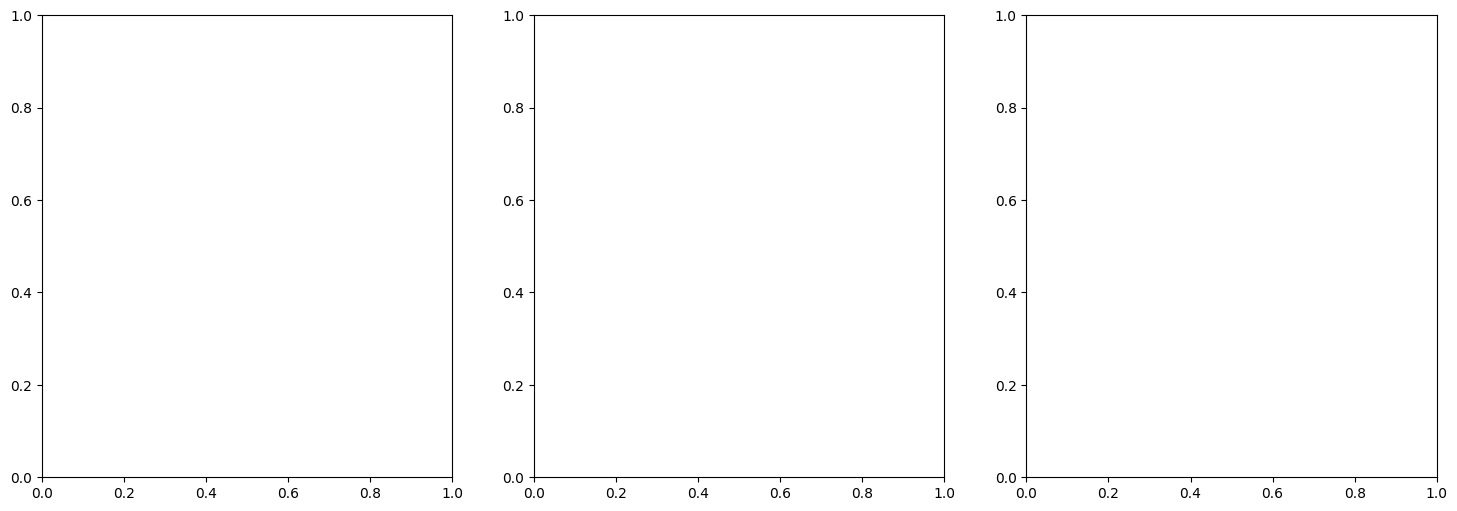

In [ ]:
import matplotlib.pyplot as plt

# 1. Plot performance metrics comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['RMSE', 'MAE', 'R²']
colors = ['#1f77b4', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df['Model'], results_df[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison', fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, height*1.02,
                    f'{height:.2f}',
                    ha='center', va='bottom')

# 2. Plot predictions vs actual values
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))
for idx, (model_name, model) in enumerate(models.items()):
    y_pred = results_df[results_df['Model'] == model_name]['Predictions'].iloc[0]
    axes2[idx].scatter(y_test, y_pred, alpha=0.5, color=colors[idx])
    axes2[idx].plot([y_test.min(), y_test.max()], 
                   [y_test.min(), y_test.max()], 
                   'k--', lw=2)
    axes2[idx].set_title(f'{model_name}\nActual vs Predicted', fontweight='bold')
    axes2[idx].set_xlabel('True Values')
    axes2[idx].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

## portfolio performance


In [ ]:
portfolio_results = {
    'Model': [],
    'Avg Return': [],
    'Volatility': [],
    'Sharpe Ratio': []
}

risk_free_rate = 0  # Set your risk-free rate here

for i, name in enumerate(results['Model']):
    y_pred = results['Predictions'][i]
    # Use sign of prediction as position
    positions = np.sign(y_pred)
    strat_returns = positions * y_test.values

    avg_return = np.mean(strat_returns)
    volatility = np.std(strat_returns)
    sharpe = (avg_return - risk_free_rate) / (volatility + 1e-8)

    portfolio_results['Model'].append(name)
    portfolio_results['Avg Return'].append(avg_return)
    portfolio_results['Volatility'].append(volatility)
    portfolio_results['Sharpe Ratio'].append(sharpe)

portfolio_df = pd.DataFrame(portfolio_results)
print("Portfolio Performance Metrics:\n")
print(portfolio_df)

Portfolio Performance Metrics:

               Model  Avg Return  Volatility  Sharpe Ratio
0  Linear Regression    0.035723    0.220558      0.161965
1      Random Forest    0.016866    0.222795      0.075703
2     Neural Network    0.039511    0.219911      0.179670
